In [11]:
from __future__ import annotations

from ase.visualize import view

from oxide_utils import (
    get_structure,
    make_slab,
    patch_slab_helpers,
    stabilize_slab_by_best_effort_move,
)

from slab_supercell import make_slab_xy_supercell_from_ouc

patch_slab_helpers()

def view_structure(structure, viewer: str = "ase"):
    return view(structure.to_ase_atoms(), viewer=viewer)

mp_id = "mp-1265"

structure = get_structure(mp_id).to_conventional()
slab = make_slab(structure, miller_index=(1, 1, 1), min_slab_size=50, min_vacuum_size=10,)
slab = slab.make_supercell([2, 2, 1])
slab_stabilized = slab.copy()
solution = stabilize_slab_by_best_effort_move(slab_stabilized)
slab_stabilized.add_oxidation_state_by_guess()

Structure Summary
Lattice
    abc : 5.931215619675673 5.931215619675673 65.3780332018392
 angles : 90.0 90.0 120.00000000000001
 volume : 1991.8191698305288
      A : np.float64(5.931215619675673) np.float64(0.0) np.float64(3.6318221118442994e-16)
      B : np.float64(-2.9656078098378384) np.float64(5.136583401962193) np.float64(3.6318221118442994e-16)
      C : np.float64(0.0) np.float64(0.0) np.float64(65.3780332018392)
    pbc : True True True
PeriodicSite: Mg2+ (1.483, 2.568, 1.292e-15) [0.5, 0.5, 1.421e-17]
PeriodicSite: Mg2+ (2.966, 0.0, 50.85) [0.5, 0.0, 0.7778]
PeriodicSite: Mg2+ (4.448, 2.568, 1.474e-15) [1.0, 0.5, 1.421e-17]
PeriodicSite: Mg2+ (0.0, 0.0, 9.293e-16) [0.0, 0.0, 1.421e-17]
PeriodicSite: Mg2+ (1.483, 0.8561, 2.421) [0.3333, 0.1667, 0.03704]
PeriodicSite: Mg2+ (-1.554e-15, 3.424, 2.421) [0.3333, 0.6667, 0.03704]
PeriodicSite: Mg2+ (4.448, 0.8561, 2.421) [0.8333, 0.1667, 0.03704]
PeriodicSite: Mg2+ (2.966, 3.424, 2.421) [0.8333, 0.6667, 0.03704]
PeriodicSite: Mg2+ 

In [12]:
slab_stabilized.to_ase_atoms().write('file.xyz')

In [13]:
from pymatgen.core.surface import Slab
from pymatgen.core.lattice import Lattice


def set_c(slab, c):
    lattice = slab.lattice
    lattice = Lattice.from_parameters(
        a=lattice.a,
        b=lattice.b,
        c=c,
        alpha=lattice.alpha,
        beta=lattice.beta,
        gamma=lattice.gamma,
    )
    return Slab(
        lattice,
        slab.species,
        slab.cart_coords,
        slab.miller_index,
        slab.oriented_unit_cell,
        slab.shift,
        slab.scale_factor,
        coords_are_cartesian=True,
        site_properties=slab.site_properties,
    )

In [14]:
slab_long = set_c(slab_stabilized, 100)

In [15]:
view_structure(slab_long)

<Popen: returncode: None args: ['/Users/tw/miniforge3/envs/surfpes/bin/pytho...>

In [16]:
from ewald import get_ewald_energy

get_ewald_energy(slab_long, [True, True, False])

tensor([-3986.8412])

## Cleavage energy vs slab thickness (Ewald)
We compute an electrostatic cleavage-like energy density for each slab thickness as

$$\gamma = \frac{E_{\mathrm{slab}} - N\,E_{\mathrm{bulk\,ouc}}}{2A}$$

where $N$ is the number of oriented unit cells in the slab, and $A$ is the slab surface area.

,min_slab_size,num_layers,sites,surface_area,N_ouc,E_bulk_per_ouc,E_slab_stable,E_slab_unstable,gamma,gamma_stable,gamma_unstable
0,8.0,2,48,30.466184,2.0,-576.006716,-1106.807667,-471.080557,0.741901,0.741901,11.175224
1,12.0,2,48,30.466184,2.0,-576.006716,-1106.807667,-471.080557,0.741901,0.741901,11.175224
2,16.0,3,72,30.466184,3.0,-576.006716,-1682.814380,-701.925308,0.741901,0.741901,16.839898
3,20.0,3,72,30.466184,3.0,-576.006716,-1682.814380,-701.925308,0.741901,0.741901,16.839898
4,24.0,4,96,30.466184,4.0,-576.006716,-2258.821096,-932.770060,0.741901,0.741901,22.504571
5,28.0,4,96,30.466184,4.0,-576.006716,-2258.821096,-932.770060,0.741901,0.741901,22.504571
6,32.0,5,120,30.466184,5.0,-576.006716,-2834.827813,-1163.614811,0.741901,0.741901,28.169245
7,36.0,5,120,30.466184,5.0,-576.006716,-2834.827813,-1163.614811,0.741901,0.741901,28.169245
8,40.0,6,144,30.466184,6.0,-576.006716,-3410.834529,-1394.459563,0.741901,0.741901,33.833918
9,44.0,7,168,30.466184,7.0,-576.006716,-3986.841245,-1625.304314,0.741901,0.741901,39.498592


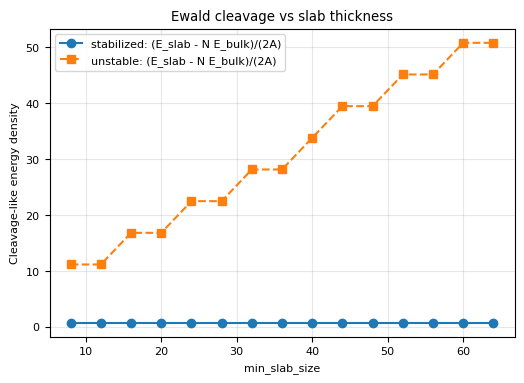

In [17]:
import numpy as np

def _to_float_energy(energy):
    return float(energy.item() if hasattr(energy, "item") else energy)

def _bulk_ewald_per_oriented_unit_cell(slab_like):
    ouc = slab_like.oriented_unit_cell.copy()
    ouc.add_oxidation_state_by_guess()
    return _to_float_energy(get_ewald_energy(ouc, [True, True, True]))

def cleavage_vs_thickness(
    structure,
    miller_index=(1, 1, 1),
    thicknesses=range(8, 68, 4),
    min_vacuum_size=10.0,
    xy_supercell=(2, 2),
    c_nonperiodic=100.0,
    pbc_slab=(True, True, False),
):
    rows = []
    bulk_e_per_ouc = None

    for min_slab_size in thicknesses:
        try:
            slab_i = make_slab(
                structure,
                miller_index=miller_index,
                min_slab_size=float(min_slab_size),
                min_vacuum_size=float(min_vacuum_size),
            )
            slab_i = slab_i.make_supercell([xy_supercell[0], xy_supercell[1], 1])
            slab_unstable = slab_i.copy()
            stabilize_slab_by_best_effort_move(slab_i)

            slab_i.add_oxidation_state_by_guess()
            slab_unstable.add_oxidation_state_by_guess()

            slab_i = set_c(slab_i, c_nonperiodic)
            slab_unstable = set_c(slab_unstable, c_nonperiodic)

            if bulk_e_per_ouc is None:
                bulk_e_per_ouc = _bulk_ewald_per_oriented_unit_cell(slab_i)

            e_slab_stable = _to_float_energy(get_ewald_energy(slab_i, list(pbc_slab)))
            e_slab_unstable = _to_float_energy(get_ewald_energy(slab_unstable, list(pbc_slab)))

            n_ouc = len(slab_i) / len(slab_i.oriented_unit_cell)
            area = float(slab_i.surface_area)

            gamma_stable = (e_slab_stable - n_ouc * bulk_e_per_ouc) / (2.0 * area)
            gamma_unstable = (e_slab_unstable - n_ouc * bulk_e_per_ouc) / (2.0 * area)

            rows.append(
                {
                    "min_slab_size": float(min_slab_size),
                    "num_layers": int(slab_i.num_layers),
                    "sites": int(len(slab_i)),
                    "surface_area": area,
                    "N_ouc": float(n_ouc),
                    "E_bulk_per_ouc": bulk_e_per_ouc,
                    "E_slab_stable": e_slab_stable,
                    "E_slab_unstable": e_slab_unstable,
                    "gamma": gamma_stable,
                    "gamma_stable": gamma_stable,
                    "gamma_unstable": gamma_unstable,
                }
            )
        except Exception as exc:
            rows.append(
                {
                    "min_slab_size": float(min_slab_size),
                    "error": str(exc),
                }
            )

    return rows

rows = cleavage_vs_thickness(
    structure=structure,
    miller_index=(1, 1, 1),
    thicknesses=range(8, 68, 4),
    min_vacuum_size=10.0,
    xy_supercell=(2, 2),
    c_nonperiodic=100.0,
    pbc_slab=(True, True, False),
)

ok_rows = [r for r in rows if "error" not in r]
err_rows = [r for r in rows if "error" in r]

try:
    import pandas as pd
    display(pd.DataFrame(ok_rows))
    if err_rows:
        print("Skipped thicknesses due to errors:")
        display(pd.DataFrame(err_rows))
except Exception:
    print(ok_rows)
    if err_rows:
        print("Skipped thicknesses due to errors:")
        print(err_rows)

if ok_rows:
    x = np.array([r["min_slab_size"] for r in ok_rows], dtype=float)
    y_stable = np.array([r["gamma_stable"] for r in ok_rows], dtype=float)
    y_unstable = np.array([r["gamma_unstable"] for r in ok_rows], dtype=float)

    try:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(6, 4))
        plt.plot(x, y_stable, "o-", label="stabilized: (E_slab - N E_bulk)/(2A)")
        plt.plot(x, y_unstable, "s--", label="unstable: (E_slab - N E_bulk)/(2A)")
        plt.xlabel("min_slab_size")
        plt.ylabel("Cleavage-like energy density")
        plt.title("Ewald cleavage vs slab thickness")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    except Exception as exc:
        print(f"Plot skipped: {exc}")